# Analiza Open Library skupa podataka

Skup podataka preuzet je sa projekta Open Library (Internet Archive) u obliku mesecnih dump fajlova.
Koriste se tri kolekcije:

- `works` - knjizevna dela na konceptualnom nivou (naslov, autori, teme, godina objavljivanja)
- `authors` - podaci o autorima (ime, datum rodjenja i smrti, biografija)
- `ratings` - korisnicke ocene dela (vrednost od 1 do 5)

Cilj analize je odgovaranje na deset pitanja postavljenih iz perspektive razlicitih uloga,
nakon cega sledi kreiranje indeksa za optimizaciju upita.

## Priprema okruzenja

Povezivanje sa lokalnom MongoDB instancom i definisanje kolekcija.

In [77]:
from pymongo import MongoClient, ASCENDING, DESCENDING
import json
import time

client = MongoClient("mongodb://localhost:27017/")
db = client["open_library"]

works = db["works"]
authors = db["authors"]
ratings = db["ratings"]

vremena = {}


In [51]:
timeout_upiti = {}
TIMEOUT_VREME = 120

## Ucitavanje podataka

Dump fajlovi za `works` i `authors` su tab-separated, gde svaki red ima pet kolona:
tip zapisa, kljuc, revizija, datum izmene i JSON dokument. Od interesa je peta kolona.

Fajlovi su veliki (works 23 GB, authors 6 GB) pa se citaju red po red bez ucitavanja u memoriju.
Ucitavanje se vrsi u serijama radi brzine, a neispravni JSON redovi se preskacu uz brojanje.

In [2]:
def ucitaj_dump(putanja, kolekcija, ocekivani_tip, batch_size=1000):
    kolekcija.drop()
    batch = []
    ubaceno = 0
    preskoceno = 0
    with open(putanja, "r", encoding="utf-8") as f:
        for i, linija in enumerate(f):
            delovi = linija.split("\t")
            if len(delovi) < 5:
                preskoceno += 1
                continue
            if delovi[0] != ocekivani_tip:
                continue
            try:
                dokument = json.loads(delovi[4])
            except json.JSONDecodeError:
                preskoceno += 1
                continue
            batch.append(dokument)
            if len(batch) >= batch_size:
                kolekcija.insert_many(batch)
                ubaceno += len(batch)
                batch = []
            if (i + 1) % 100000 == 0:
                print(f"  obradjeno redova: {i + 1:,} | ubaceno: {ubaceno:,}")
    if batch:
        kolekcija.insert_many(batch)
        ubaceno += len(batch)
    print(f"Zavrseno. Ubaceno: {ubaceno:,} | preskoceno: {preskoceno:,}")
    return ubaceno

In [3]:
print("Ucitavanje works kolekcije...")
ucitaj_dump("ol_dump_works_2026-05-31.txt", works, "/type/work")

Ucitavanje works kolekcije...
  obradjeno redova: 100,000 | ubaceno: 100,000
  obradjeno redova: 200,000 | ubaceno: 200,000
  obradjeno redova: 300,000 | ubaceno: 300,000
  obradjeno redova: 400,000 | ubaceno: 400,000
  obradjeno redova: 500,000 | ubaceno: 500,000
  obradjeno redova: 600,000 | ubaceno: 600,000
  obradjeno redova: 700,000 | ubaceno: 700,000
  obradjeno redova: 800,000 | ubaceno: 800,000
  obradjeno redova: 900,000 | ubaceno: 900,000
  obradjeno redova: 1,000,000 | ubaceno: 1,000,000
  obradjeno redova: 1,100,000 | ubaceno: 1,100,000
  obradjeno redova: 1,200,000 | ubaceno: 1,200,000
  obradjeno redova: 1,300,000 | ubaceno: 1,300,000
  obradjeno redova: 1,400,000 | ubaceno: 1,400,000
  obradjeno redova: 1,500,000 | ubaceno: 1,500,000
  obradjeno redova: 1,600,000 | ubaceno: 1,600,000
  obradjeno redova: 1,700,000 | ubaceno: 1,700,000
  obradjeno redova: 1,800,000 | ubaceno: 1,800,000
  obradjeno redova: 1,900,000 | ubaceno: 1,900,000
  obradjeno redova: 2,000,000 | ubace

41269406

In [4]:
print("Ucitavanje authors kolekcije...")
ucitaj_dump("ol_dump_authors_2026-05-31.txt", authors, "/type/author")

Ucitavanje authors kolekcije...
  obradjeno redova: 100,000 | ubaceno: 100,000
  obradjeno redova: 200,000 | ubaceno: 200,000
  obradjeno redova: 300,000 | ubaceno: 300,000
  obradjeno redova: 400,000 | ubaceno: 400,000
  obradjeno redova: 500,000 | ubaceno: 500,000
  obradjeno redova: 600,000 | ubaceno: 600,000
  obradjeno redova: 700,000 | ubaceno: 700,000
  obradjeno redova: 800,000 | ubaceno: 800,000
  obradjeno redova: 900,000 | ubaceno: 900,000
  obradjeno redova: 1,000,000 | ubaceno: 1,000,000
  obradjeno redova: 1,100,000 | ubaceno: 1,100,000
  obradjeno redova: 1,200,000 | ubaceno: 1,200,000
  obradjeno redova: 1,300,000 | ubaceno: 1,300,000
  obradjeno redova: 1,400,000 | ubaceno: 1,400,000
  obradjeno redova: 1,500,000 | ubaceno: 1,500,000
  obradjeno redova: 1,600,000 | ubaceno: 1,600,000
  obradjeno redova: 1,700,000 | ubaceno: 1,700,000
  obradjeno redova: 1,800,000 | ubaceno: 1,800,000
  obradjeno redova: 1,900,000 | ubaceno: 1,900,000
  obradjeno redova: 2,000,000 | uba

15292520

In [5]:
def ucitaj_ratings(putanja, kolekcija, batch_size=1000):
    kolekcija.drop()
    batch = []
    ubaceno = 0
    preskoceno = 0
    with open(putanja, "r", encoding="utf-8") as f:
        for linija in f:
            delovi = linija.rstrip("\n").split("\t")
            if len(delovi) < 4:
                preskoceno += 1
                continue
            try:
                dokument = {
                    "work_key": delovi[0],
                    "rating": int(delovi[2]),
                    "date": delovi[3]
                }
            except ValueError:
                preskoceno += 1
                continue
            batch.append(dokument)
            if len(batch) >= batch_size:
                kolekcija.insert_many(batch)
                ubaceno += len(batch)
                batch = []
    if batch:
        kolekcija.insert_many(batch)
        ubaceno += len(batch)
    print(f"Zavrseno. Ubaceno: {ubaceno:,} | preskoceno: {preskoceno:,}")
    return ubaceno

In [6]:
print("Ucitavanje ratings kolekcije...")
ucitaj_ratings("ol_dump_ratings_2026-05-31.txt", ratings)

Ucitavanje ratings kolekcije...
Zavrseno. Ubaceno: 621,724 | preskoceno: 0


621724

In [7]:
print("works  :", works.count_documents({}))
print("authors:", authors.count_documents({}))
print("ratings:", ratings.count_documents({}))

works  : 41269406
authors: 15292520
ratings: 621724


In [8]:
N = 200000

ratings_sample = db["ratings_sample"]
works_sample = db["works_sample"]
authors_sample = db["authors_sample"]

ratings_sample.drop()
works_sample.drop()
authors_sample.drop()

ratings_sample.insert_many(list(ratings.find().limit(N)))
works_sample.insert_many(list(works.find().sort("last_modified.value", -1).limit(N)))
authors_sample.insert_many(list(authors.find().limit(N)))

print(f"ratings_sample: {ratings_sample.count_documents({}):,}")
print(f"works_sample: {works_sample.count_documents({}):,}")
print(f"authors_sample: {authors_sample.count_documents({}):,}")

ratings_sample: 200,000
works_sample: 200,000
authors_sample: 200,000


## Analiticki upiti

Sledi niz analitickih pitanja nad kolekcijama `works`, `authors` i `ratings`. Za svako pitanje prvo se kreira odgovarajuci indeks (ili vise njih), a zatim se izvrsava agregacioni upit. Indeksi su birani prema poljima koja se koriste za filtriranje, spajanje i sortiranje, uz primenu ESR pravila (Equality, Sort, Range).

In [9]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 1 - Dela objavljena izmedju 1480. i 1500. godine

Vraca 50 dela ciji datum prvog objavljivanja (`first_publish_date`) pada u opseg od 1480. do 1500. godine, poredjanih hronoloski od najstarijeg ka najnovijem. Prikazuje godinu i naslov.

In [10]:
pipeline = [
    {"$match": {
        "first_publish_date": {"$gte": "1480", "$lte": "1500"}
    }},
    {"$sort": {"first_publish_date": 1}},
    {"$limit": 50},
    {"$project": {
        "_id": 0,
        "title": 1,
        "godina": "$first_publish_date"
    }}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("godina", ""):>12}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 1", {})["neopt"] = _dt


        1480  [ Casus summarii decretalium Sexti et Clementinarum]
        1480  Mishneh Torah (Codification of Talmudic laws)
        1480  Singularia iuris
        1480  Chirurgia
        1480  Liber missarum et motectorum
        1480  De evangelica praeparatione
        1480  Petrus de Alyaco ... Tractatus de ymagine mundi
        1480  Elegantiolae
        1480  Chronica virorum illustrium
        1480  De ingenuis moribus ac liberalibus studiis
        1480  Tractatus de ymagine mundi..
        1480  Explicit liber modo[rum] sig[nifica]ndi Alberti
        1480  Perush Daniʾel
        1480  Sermones quadragesimales de poenitentia
        1481  [Summa theologica]
        1481  Speculum aureum decem praeceptorum
        1481  G. Jul. Cesaris Oratio Versontione belgice ad milites habita
        1481  Judean antiquities 1-4
        1481  Contra Celsum
        1481  Summa theologia
        1481  De corpore christi theoremata L, sive Theoremata de hostia consecreta
        1481  Dialogu

In [11]:
works.create_index([("first_publish_date", 1)])

'first_publish_date_1'

In [12]:
pipeline = [
    {"$match": {
        "first_publish_date": {"$gte": "1900", "$lte": "1950"}
    }},
    {"$sort": {"first_publish_date": 1}},
    {"$limit": 50},
    {"$project": {
        "_id": 0,
        "title": 1,
        "godina": "$first_publish_date"
    }}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("godina", ""):>12}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 1", {})["opt"] = _dt


        1900  Grundzüge der italienischen und französischen Metrik
        1900  Institucions del furs y privilegis del regne de Valencia ..
        1900  Mrs. Cherry's sister; or, Christian science at Fairfax
        1900  ʻIndamā tumṭir al-nujūm
        1900  The story of Old Market Street Bible Class
        1900  On expressed yeast-cell plasma
        1900  Thoughts ... garnered by the way
        1900  Lenore
        1900  The Great Famine and Its Causes
        1900  Elements of Rhetoric and English Composition: Second High School Course
        1900  La guerra Hispano-americana: La Habana, influencia de las plazas de guerra
        1900  Fulham Old and New: Being an Exhaustive History of the Ancient Parish of Fulham
        1900  Verfassung und Verwaltung sämtlicher Religions-genossenschaften in Bayern
        1900  The Golden Caribbean: A Winter Visit to the Republics of Colombia, Costa Rica, Spanish Honduras ..
        1900  Light in the East
        1900  Six Decades in Texas

In [13]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 2 - Broj dela o Londonu azuriranih u poslednjih 10 godina, po godinama 

Za dela vezana za London, broji koliko ih je azurirano u svakoj godini od 2016. do 2026. Vraca po jedan red za svaku godinu sa pripadajucim brojem dela.

In [14]:
mesto = "London"

pipeline = [
    {"$match": {"subject_places": mesto}},
    {"$addFields": {
        "godina": {"$toInt": {"$substr": ["$last_modified.value", 0, 4]}}
    }},
    {"$match": {"godina": {"$gte": 2016, "$lte": 2026}}},
    {"$group": {"_id": "$godina", "broj_dela": {"$sum": 1}}},
    {"$sort": {"_id": -1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["_id"]}:  {red["broj_dela"]:>6,}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 2", {})["neopt"] = _dt


2026:   1,650
2025:   3,497
2024:   2,505
2023:   2,063
2022:   3,430
2021:   1,889
2020:   2,155
2019:     829
2018:     175
2017:     345
2016:      89
Vreme izvrsavanja: 64.430693 s


In [15]:
works.create_index([("subject_places", 1), ("last_modified.value", -1)])

'subject_places_1_last_modified.value_-1'

In [16]:
mesto = "London"

pipeline = [
    {"$match": {"subject_places": mesto}},
    {"$addFields": {
        "godina": {"$toInt": {"$substr": ["$last_modified.value", 0, 4]}}
    }},
    {"$match": {"godina": {"$gte": 2016, "$lte": 2026}}},
    {"$group": {"_id": "$godina", "broj_dela": {"$sum": 1}}},
    {"$sort": {"_id": -1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["_id"]}:  {red["broj_dela"]:>6,}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 2", {})["opt"] = _dt


2026:   1,650
2025:   3,497
2024:   2,505
2023:   2,063
2022:   3,430
2021:   1,889
2020:   2,155
2019:     829
2018:     175
2017:     345
2016:      89
Vreme izvrsavanja: 0.116611 s


In [17]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 3 - Najcesce revidirana dela o 20. veku

Vraca 40 dela koja obradjuju period 20. veka (`subject_times` sadrzi "20th century"), poredjanih po broju revizija zapisa opadajuce. Veliki broj revizija ukazuje na zapise koji su privlacili najvise uredjivanja.

In [18]:
period = "20th century"

pipeline = [
    {"$match": {"subject_times": period}},
    {"$sort": {"revision": -1}},
    {"$limit": 40},
    {"$project": {"_id": 0, "title": 1, "revision": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("revision", 0):>4}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 3", {})["neopt"] = _dt


 467  Kuze Teruhiko vs. Mukōda Kuniko
 105  Of Mice and Men
 105  Lolita
 101  East of Eden
 101  Julius Caesar
  95  Picasso
  91  Gone With the Wind
  84  A Midsummer Night's Dream
  78  The Secret Garden
  74  On Writing
  73  The Call of the Wild
  72  La Nuit
  71  King Lear
  69  The Picture of Dorian Gray
  67  Different Seasons
  67  Hanʼguk sosŏl ŭi pundan iyagi
  65  Bridget Jones's Diary
  60  Cien años de soledad
  59  Desperation
  58  The Old Man and the Sea
  57  A Farewell to Arms
  54  Hearts in Atlantis
  51  Christian doctrine in the light of Michael Polanyi's theory of personal knowledge
  51  The Man Who Was Thursday
  51  I Know Why the Caged Bird Sings
  51  Nineteen Eighty-Four
  49  John Barleycorn
  49  À la recherche du temps perdu
  48  Marc Chagall
  47  Bud, Not Buddy
  46  Pollyanna
  46  Tosca
  46  El amor en los tiempos del cólera
  45  Andy Warhol
  45  Tarzan of the Apes
  45  Implementation of the Helsinki accords
  44  Cross
  43  Joseph Beuys
  

In [19]:
works.create_index([("subject_times", 1), ("revision", -1)])

'subject_times_1_revision_-1'

In [20]:
period = "20th century"

pipeline = [
    {"$match": {"subject_times": period}},
    {"$sort": {"revision": -1}},
    {"$limit": 40},
    {"$project": {"_id": 0, "title": 1, "revision": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("revision", 0):>4}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 3", {})["opt"] = _dt


 467  Kuze Teruhiko vs. Mukōda Kuniko
 105  Lolita
 105  Of Mice and Men
 101  East of Eden
 101  Julius Caesar
  95  Picasso
  91  Gone With the Wind
  84  A Midsummer Night's Dream
  78  The Secret Garden
  74  On Writing
  73  The Call of the Wild
  72  La Nuit
  71  King Lear
  69  The Picture of Dorian Gray
  67  Hanʼguk sosŏl ŭi pundan iyagi
  67  Different Seasons
  65  Bridget Jones's Diary
  60  Cien años de soledad
  59  Desperation
  58  The Old Man and the Sea
  57  A Farewell to Arms
  54  Hearts in Atlantis
  51  Nineteen Eighty-Four
  51  The Man Who Was Thursday
  51  Christian doctrine in the light of Michael Polanyi's theory of personal knowledge
  51  I Know Why the Caged Bird Sings
  49  À la recherche du temps perdu
  49  John Barleycorn
  48  Marc Chagall
  47  Bud, Not Buddy
  46  Pollyanna
  46  El amor en los tiempos del cólera
  46  Tosca
  45  Implementation of the Helsinki accords
  45  Andy Warhol
  45  Tarzan of the Apes
  44  Cross
  43  Joseph Beuys
  

In [21]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 4 - Koji su najčešći žanrovi dela kojima je radnja u periodu Prvog svetskog rata

Za dela koja obradjuju Prvi svetski rat (`subject_times` sadrzi "WWI"), izdvaja sve teme (`subjects`) i broji koliko se puta svaka pojavljuje. Vraca 30 najcescih tema u tom skupu dela.

In [22]:
period = "WWI"

pipeline = [
    {"$match": {"subject_times": period}},
    {"$unwind": "$subjects"},
    {"$group": {"_id": "$subjects", "broj_dela": {"$sum": 1}}},
    {"$sort": {"broj_dela": -1}},
    {"$limit": 30}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["broj_dela"]:>6,}  {red["_id"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 4", {})["neopt"] = _dt


     6  Fiction
     4  World War, 1914-1918
     3  History
     2  Love
     2  Children's fiction
     2  Biography
     2  World War, 1939-1945
     2  Fiction, historical
     2  Fiction, general
     2  WWI
     1  Ireland, history, easter rising, 1916, fiction
     1  Ljubezen
     1  Continental european fiction (fictional works by one author)
     1  World war, 1914-1918, fiction
     1  Germany, biography
     1  Military history, modern
     1  Loss
     1  World war, 1914-1918, great britain
     1  World War (1914-1918) fast (OCoLC)fst01180746
     1  Fiction, religious
     1  Zgodovina
     1  Irregular warfare--history
     1  Horsemanship
     1  Social classes
     1  Somme, 1st Battle of the, France, 1916
     1  English Personal narratives
     1  Country homes
     1  Poètes russes
     1  Drawing
     1  Grandmothers
Vreme izvrsavanja: 55.041542 s


In [23]:
works.create_index([("subject_times", 1)])

'subject_times_1'

In [24]:
period = "WWI"

pipeline = [
    {"$match": {"subject_times": period}},
    {"$unwind": "$subjects"},
    {"$group": {"_id": "$subjects", "broj_dela": {"$sum": 1}}},
    {"$sort": {"broj_dela": -1}},
    {"$limit": 30}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["broj_dela"]:>6,}  {red["_id"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 4", {})["opt"] = _dt


     6  Fiction
     4  World War, 1914-1918
     3  History
     2  Biography
     2  World War, 1939-1945
     2  Fiction, general
     2  Children's fiction
     2  WWI
     2  Love
     2  Fiction, historical
     1  Families
     1  Duckworth
     1  English Spy stories
     1  Air pilots, fiction
     1  Epic literature
     1  Great britain, history, fiction
     1  Littérature
     1  Russian Revolution
     1  Flambards (England : Imaginary place)
     1  Hitler, adolf, 1889-1945
     1  Infantry drill and tactics
     1  US Steel
     1  Novels
     1  Prohibited book
     1  Russian poetry
     1  Czar Nicholas II
     1  Cartoons, paintings
     1  355.02/18
     1  Zdravniki
     1  Littérature russe
Vreme izvrsavanja: 0.049484 s


In [25]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 5 - Najbolje ocenjena dela na osnovu ocena postavljenih posle 2020

Iz ocena datih od 2020. godine naovamo, racuna prosecnu ocenu i broj ocena po delu, zadrzava samo dela sa najmanje 5 ocena i vraca 20 najbolje ocenjenih. Naslov dela se dobija spajanjem (`$lookup`) sa kolekcijom `works`.

In [ ]:
pipeline = [
    {"$match": {"date": {"$gte": "2020-01-01"}}},
    {"$group": {
        "_id": "$work_key",
        "prosecna_ocena": {"$avg": "$rating"},
        "broj_ocena": {"$sum": 1}
    }},
    {"$match": {"broj_ocena": {"$gte": 5}}},
    {"$sort": {"prosecna_ocena": -1, "broj_ocena": -1}},
    {"$limit": 20},
    {"$lookup": {
        "from": "works",
        "localField": "_id",
        "foreignField": "key",
        "as": "delo"
    }},
    {"$unwind": "$delo"},
    {"$project": {
        "_id": 0,
        "title": "$delo.title",
        "prosecna_ocena": 1,
        "broj_ocena": 1
    }}
]

_t0 = time.perf_counter()
for red in ratings.aggregate(pipeline, allowDiskUse=True):
    print(f'{red["prosecna_ocena"]:.2f}  ({red["broj_ocena"]} ocena)  {red["title"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 5", {})["neopt"] = _dt


In [110]:
pipeline = [
    {"$match": {"date": {"$gte": "2020-01-01"}}},
    {"$group": {
        "_id": "$work_key",
        "prosecna_ocena": {"$avg": "$rating"},
        "broj_ocena": {"$sum": 1}
    }},
    {"$match": {"broj_ocena": {"$gte": 1}}},
    {"$sort": {"prosecna_ocena": -1, "broj_ocena": -1}},
    {"$limit": 20},
    {"$lookup": {
        "from": "works_sample",
        "localField": "_id",
        "foreignField": "key",
        "as": "delo"
    }},
    {"$unwind": "$delo"},
    {"$project": {
        "_id": 0,
        "title": "$delo.title",
        "prosecna_ocena": 1,
        "broj_ocena": 1
    }}
]

for red in ratings_sample.aggregate(pipeline, allowDiskUse=True):
    print(f'{red["prosecna_ocena"]:.2f}  ({red["broj_ocena"]} ocena)  {red["title"]}')

5.00  (11 ocena)  Diary of an 8-Bit Warrior #3


In [52]:
vremena.setdefault("Upit 5", {})["neopt"] = TIMEOUT_VREME
timeout_upiti["Upit 5"] = True

In [26]:
ratings.create_index([("date", 1), ("work_key", 1), ("rating", 1)])
works.create_index([("key", 1)])

'key_1'

In [27]:
pipeline = [
    {"$match": {"date": {"$gte": "2020-01-01"}}},
    {"$group": {
        "_id": "$work_key",
        "prosecna_ocena": {"$avg": "$rating"},
        "broj_ocena": {"$sum": 1}
    }},
    {"$match": {"broj_ocena": {"$gte": 5}}},
    {"$sort": {"prosecna_ocena": -1, "broj_ocena": -1}},
    {"$limit": 20},
    {"$lookup": {
        "from": "works",
        "localField": "_id",
        "foreignField": "key",
        "as": "delo"
    }},
    {"$unwind": "$delo"},
    {"$project": {
        "_id": 0,
        "title": "$delo.title",
        "prosecna_ocena": 1,
        "broj_ocena": 1
    }}
]

_t0 = time.perf_counter()
for red in ratings.aggregate(pipeline, allowDiskUse=True):
    print(f'{red["prosecna_ocena"]:.2f}  ({red["broj_ocena"]} ocena)  {red["title"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 5", {})["opt"] = _dt


5.00  (43 ocena)  Night Owl
5.00  (12 ocena)  NEXT-GEN LUXE INFRASTRUCTURE PLAN
5.00  (12 ocena)  The eBook Publisher’s Handbook
5.00  (12 ocena)  Easily Learn Bengali
5.00  (12 ocena)  The Independent Musician’s Blueprint
5.00  (11 ocena)  Diary of an 8-Bit Warrior #3
5.00  (11 ocena)  Moon Rising
5.00  (11 ocena)  The Silver Rings
5.00  (10 ocena)  Here is Portugal
5.00  (10 ocena)  The revenge of the baby-sat
5.00  (10 ocena)  Back To Eden
5.00  (10 ocena)  The scar
5.00  (10 ocena)  The Power of Logic
5.00  (10 ocena)  Португалія Ось i зараз
5.00  (10 ocena)  To Selena, with love
5.00  (9 ocena)  Camp Damascus
5.00  (9 ocena)  Ringkasan sejarat filsafat
5.00  (9 ocena)  Splat the Cat
5.00  (9 ocena)  How I made one million dollars last year trading commodities
5.00  (9 ocena)  Revelaciones
Vreme izvrsavanja: 1.128063 s


In [28]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 6 - Istorijski periodi u delima vezanim za Srbiju

Za dela tematski vezana za Srbiju (`subject_places` sadrzi "Serbia"), izdvaja istorijske periode (`subject_times`) i broji koliko ih dela obradjuje. Vraca 20 najcescih perioda. Koristi parcijalni (partial) indeks koji obuhvata samo dela koja imaju polje `subject_times`.

In [29]:
pipeline = [
    {"$match": {
        "subject_places": "Serbia",
        "subject_times": {"$exists": True, "$ne": []}
    }},
    {"$unwind": "$subject_times"},
    {"$group": {"_id": "$subject_times", "broj_dela": {"$sum": 1}}},
    {"$sort": {"broj_dela": -1}},
    {"$limit": 20},
    {"$project": {"_id": 0, "period": "$_id", "broj_dela": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["broj_dela"]:>5,}  {red["period"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 6", {})["neopt"] = _dt


1,387  20th century
  568  1804-1918
  459  19th century
  359  21st century
  305  1992-
  261  To 1456
  216  1918-1945
  210  1992-2006
  195  Insurrection, 1804-1813
  168  1945-1992
  113  2006-
  100  1992-2003
   86  18th century
   84  1980-1992
   80  War of 1912-1913
   73  Civil War, 1998-1999
   64  1945-
   63  1456-1804
   50  Axis occupation, 1941-1945
   47  1945-1980
Vreme izvrsavanja: 64.235664 s


Pravi indeks na `subject_places` samo za dokumente koji koji imaju `subject_times`

In [30]:
works.create_index(
    [("subject_places", 1)],
    partialFilterExpression={"subject_times": {"$exists": True}}
)

'subject_places_1'

In [31]:
pipeline = [
    {"$match": {
        "subject_places": "Serbia",
        "subject_times": {"$exists": True, "$ne": []}
    }},
    {"$unwind": "$subject_times"},
    {"$group": {"_id": "$subject_times", "broj_dela": {"$sum": 1}}},
    {"$sort": {"broj_dela": -1}},
    {"$limit": 20},
    {"$project": {"_id": 0, "period": "$_id", "broj_dela": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["broj_dela"]:>5,}  {red["period"]}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 6", {})["opt"] = _dt


1,387  20th century
  568  1804-1918
  459  19th century
  359  21st century
  305  1992-
  261  To 1456
  216  1918-1945
  210  1992-2006
  195  Insurrection, 1804-1813
  168  1945-1992
  113  2006-
  100  1992-2003
   86  18th century
   84  1980-1992
   80  War of 1912-1913
   73  Civil War, 1998-1999
   64  1945-
   63  1456-1804
   50  Axis occupation, 1941-1945
   47  1945-1980
Vreme izvrsavanja: 1.101413 s


In [32]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 7 - Broj dela iz filozofije po decenijama

Za dela iz oblasti filozofije (`subjects` sadrzi "Philosophy") objavljena izmedju 1800. i 2020. godine, grupise ih po deceniji objavljivanja i broji koliko ih pripada svakoj deceniji. Vraca po jedan red za svaku deceniju, poredjano hronoloski.

In [33]:
pipeline = [
    {"$match": {
        "subjects": "Philosophy",
        "first_publish_date": {"$gte": "1800", "$lte": "2020"}
    }},
    {"$addFields": {
        "godina": {"$toInt": {"$substr": ["$first_publish_date", 0, 4]}}
    }},
    {"$match": {"godina": {"$gte": 1800, "$lte": 2020}}},
    {"$group": {
        "_id": {"$subtract": ["$godina", {"$mod": ["$godina", 10]}]},
        "broj_dela": {"$sum": 1}
    }},
    {"$sort": {"_id": 1}},
    {"$project": {"_id": 0, "decenija": "$_id", "broj_dela": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["decenija"]}-te:  {red["broj_dela"]:>5,}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 7", {})["neopt"] = _dt


1800-te:     32
1810-te:     17
1820-te:     36
1830-te:     56
1840-te:     92
1850-te:     93
1860-te:     83
1870-te:    117
1880-te:    154
1890-te:    177
1900-te:    328
1910-te:    254
1920-te:    415
1930-te:    591
1940-te:    807
1950-te:  1,173
1960-te:  2,341
1970-te:  3,272
1980-te:  4,719
1990-te:  10,631
2000-te:  7,405
2010-te:     37
Vreme izvrsavanja: 67.066610 s


In [34]:
works.create_index([("subjects", 1), ("first_publish_date", 1)])

'subjects_1_first_publish_date_1'

In [35]:
pipeline = [
    {"$match": {
        "subjects": "Philosophy",
        "first_publish_date": {"$gte": "1800", "$lte": "2020"}
    }},
    {"$addFields": {
        "godina": {"$toInt": {"$substr": ["$first_publish_date", 0, 4]}}
    }},
    {"$match": {"godina": {"$gte": 1800, "$lte": 2020}}},
    {"$group": {
        "_id": {"$subtract": ["$godina", {"$mod": ["$godina", 10]}]},
        "broj_dela": {"$sum": 1}
    }},
    {"$sort": {"_id": 1}},
    {"$project": {"_id": 0, "decenija": "$_id", "broj_dela": 1}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red["decenija"]}-te:  {red["broj_dela"]:>5,}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 7", {})["opt"] = _dt


1800-te:     32
1810-te:     17
1820-te:     36
1830-te:     56
1840-te:     92
1850-te:     93
1860-te:     83
1870-te:    117
1880-te:    154
1890-te:    177
1900-te:    328
1910-te:    254
1920-te:    415
1930-te:    591
1940-te:    807
1950-te:  1,173
1960-te:  2,341
1970-te:  3,272
1980-te:  4,719
1990-te:  10,631
2000-te:  7,405
2010-te:     37
Vreme izvrsavanja: 0.259021 s


In [36]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


### Pitanje 8 - Dela o Srbiji objavljena pre Drugog svetskog rata

Vraca 40 dela vezanih za Srbiju koja su objavljena zakljucno sa 1939. godinom (`first_publish_date` <= "1939"), poredjanih hronoloski. Prikazuje godinu objavljivanja i naslov.

In [37]:
pipeline = [
    {"$match": {
        "subject_places": "Serbia",
        "first_publish_date": {"$lte": "1939"}
    }},
    {"$sort": {"first_publish_date": 1}},
    {"$limit": 40},
    {"$project": {"_id": 0, "title": 1, "godina": "$first_publish_date"}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("godina", ""):>10}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 8", {})["neopt"] = _dt


      1843  A fragment of the history of Servia
      1845  Sur la Serbie
      1846  Istoriia naroda srbskog
      1852  Dečanski prvenac
      1858  Monumenta Serbica spectantia historiam Serbiae, Bosnae, Ragusii
      1858  Über Trajans steinerne Donaubrücke
      1866  Travels in the Slavonic provinces of Turkey-in-Europe
      1869  Rossīya i Serbīya
      1874  Tārīh-i vaḳ'a-'i ḥayretnümā
      1875  An account of the systems of public instruction in Belgium, Russia, Turkey, Servia and Egypt
      1875  La Serbie au XIXe siècle
      1875  Serbie et Monténégro
      1876  Nouvelle géographie universelle
      1876  Istorija srpskoga naroda
      1883  Das Königreich Serbien
      1887  Spoljašnji odnošaji Srbije novijeta vremena
      1889  Wanderings of a war-artist
      1892  A szerbek története a legrégibb kortól 1848-ig
      1893  Istorija srpskoga naroda
      1893  Prve žrtve
      1893  Istorija srpskog naroda
      1897  Uspomene iz našeg crkveno-narodnog života


In [38]:
works.create_index([("subject_places", 1), ("first_publish_date", 1)])

'subject_places_1_first_publish_date_1'

In [39]:
pipeline = [
    {"$match": {
        "subject_places": "Serbia",
        "first_publish_date": {"$lte": "1939"}
    }},
    {"$sort": {"first_publish_date": 1}},
    {"$limit": 40},
    {"$project": {"_id": 0, "title": 1, "godina": "$first_publish_date"}}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("godina", ""):>10}  {red.get("title", "(bez naslova)")}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 8", {})["opt"] = _dt


      1843  A fragment of the history of Servia
      1845  Sur la Serbie
      1846  Istoriia naroda srbskog
      1852  Dečanski prvenac
      1858  Über Trajans steinerne Donaubrücke
      1858  Monumenta Serbica spectantia historiam Serbiae, Bosnae, Ragusii
      1866  Travels in the Slavonic provinces of Turkey-in-Europe
      1869  Rossīya i Serbīya
      1874  Tārīh-i vaḳ'a-'i ḥayretnümā
      1875  La Serbie au XIXe siècle
      1875  An account of the systems of public instruction in Belgium, Russia, Turkey, Servia and Egypt
      1875  Serbie et Monténégro
      1876  Istorija srpskoga naroda
      1876  Nouvelle géographie universelle
      1883  Das Königreich Serbien
      1887  Spoljašnji odnošaji Srbije novijeta vremena
      1889  Wanderings of a war-artist
      1892  A szerbek története a legrégibb kortól 1848-ig
      1893  Istorija srpskoga naroda
      1893  Istorija srpskog naroda
      1893  Prve žrtve
      1897  Uspomene iz našeg crkveno-narodnog života


In [81]:
works.drop_indexes()
authors.drop_indexes()
ratings.drop_indexes()

print("Svi dodatni indeksi obrisani.")

Svi dodatni indeksi obrisani.


## Optimizacija šeme primenom dizajn šablona

Pored indeksiranja, performanse upita mogu se unaprediti i prilagođavanjem logičke šeme baze podataka. U ovom projektu formirana je nova kolekcija `works_prosirena`, koja objedinjuje podatke iz više kolekcija kako bi se izbegla skupa spajanja (`$lookup`) i agregacije tokom izvršavanja upita.

Primenjena su dva dizajn šablona preporučena za MongoDB:

- **Sablon proširene reference (Extended Reference Pattern)** — u okviru svakog dokumenta kolekcije `works` proširena je lista autora tako što je, pored njihove reference (`key`), dodat i naziv autora (`name`) iz kolekcije `authors`. Na taj način upiti mogu direktno prikazivati ime autora bez izvršavanja `$lookup` operacije.

- **Sablon proračunavanja (Computed Pattern)** — za svako delo unapred su izračunate i sačuvane vrednosti prosečne ocene (`prosecna_ocena`) i broja ocena (`broj_ocena`) na osnovu kolekcije `ratings`. Time se eliminiše potreba za ponovnim izvršavanjem agregacija nad ocenama prilikom svakog upita.

Na ovaj način kreirana je kolekcija `works_prosirena`, optimizovana za analitičke upite koji često koriste podatke o autorima i ocenama dela.

## Pitanje 9 - Najnovija istorijska dela sa imenima autora

Pronalazi 20 najnovijih dela iz oblasti istorije (`subjects` sadrži "History"), zatim za svako delo pronalazi odgovarajuće autore iz kolekcije `authors` pomoću `$lookup` operacije i prikazuje naslov dela zajedno sa imenima autora. Rezultati su sortirani opadajuće prema datumu poslednje izmene (`last_modified.value`).

In [ ]:
pipeline = [
    {"$match": {"subjects": "History"}},
    {"$sort": {"last_modified.value": -1}},
    {"$limit": 20},
    {"$lookup": {
        "from": "authors",
        "localField": "authors.author.key",
        "foreignField": "key",
        "as": "autor_info"
    }},
    {"$project": {
        "_id": 0,
        "title": 1,
        "autori": "$autor_info.name"
    }}
]
_t0 = time.perf_counter()
for red in works.aggregate(pipeline):
    print(f'{red.get("title", "(bez naslova)"):50}  {red.get("autori", [])}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 9", {})["neopt"] = _dt


In [111]:
pipeline = [
    {"$match": {"subjects": "History"}},
    {"$sort": {"last_modified.value": -1}},
    {"$limit": 20},
    {"$lookup": {
        "from": "authors_sample",
        "localField": "authors.author.key",
        "foreignField": "key",
        "as": "autor_info"
    }},
    {"$project": {
        "_id": 0,
        "title": 1,
        "autori": "$autor_info.name"
    }}
]
for red in works_sample.aggregate(pipeline):
    print(f'{red.get("title", "(bez naslova)"):50}  {red.get("autori", [])}')

Goodnight from London                               []
Fearless Flights of Hazel Ying Lee                  []
To Intermix With Our White Brothers                 ['Thomas N Ingersoll']
The Conquering Family                               []
Listen! God speaks                                  []
Mr. Pei's Perfect Shapes                            []
Paper Son                                           []
Who Did It First?                                   []
África en la historia y en el arte                  []
America's great game                                []
The CIA, the British left, and the Cold War         []
Paying freedom's price                              []
The price of emancipation                           []
A Concise History of Bolivia                        []
The Sinews of Power                                 []
A population history of the United States           []
Parties and Politcal Change in Bolivia              []
The Last Queen                               

In [53]:
vremena.setdefault("Upit 9", {})["neopt"] = TIMEOUT_VREME
timeout_upiti["Upit 9"] = True

In [41]:
works_computed = db["works_computed"]
works_computed.drop()

print("Racunanje ocena po delu...")
pipeline_ocene = [
    {"$group": {
        "_id": "$work_key",
        "prosecna_ocena": {"$avg": "$rating"},
        "broj_ocena": {"$sum": 1}
    }}
]

ocene_po_delu = {}
for red in ratings.aggregate(pipeline_ocene):
    ocene_po_delu[red["_id"]] = {
        "prosecna_ocena": round(red["prosecna_ocena"], 2),
        "broj_ocena": red["broj_ocena"]
    }

print("Ucitavanje autora...")
autori_po_kljucu = {}
for autor in authors.find({}, {"key": 1, "name": 1}):
    autori_po_kljucu[autor["key"]] = autor.get("name")

print("Kreiranje computed kolekcije...")
batch = []
ubaceno = 0

for delo in works.find({}):
    kljuc = delo.get("key")

    if kljuc in ocene_po_delu:
        delo["prosecna_ocena"] = ocene_po_delu[kljuc]["prosecna_ocena"]
        delo["broj_ocena"] = ocene_po_delu[kljuc]["broj_ocena"]
    else:
        delo["prosecna_ocena"] = None
        delo["broj_ocena"] = 0

    for a in delo.get("authors", []):
        if not isinstance(a, dict):
            continue
        author_obj = a.get("author")
        if not isinstance(author_obj, dict):
            continue
        author_key = author_obj.get("key")
        if author_key in autori_po_kljucu:
            author_obj["name"] = autori_po_kljucu[author_key]

    batch.append(delo)

    if len(batch) >= 1000:
        works_computed.insert_many(batch)
        ubaceno += len(batch)
        batch = []

if batch:
    works_computed.insert_many(batch)
    ubaceno += len(batch)

print(f"Zavrseno. Ubaceno: {ubaceno:,}")

Racunanje ocena po delu...
Ucitavanje autora...
Kreiranje computed kolekcije...
Zavrseno. Ubaceno: 41,269,406


#### Posle primene sablona — isti upit bez `$lookup`

In [42]:
works_computed.create_index([("subjects", 1), ("first_publish_date", -1)])

'subjects_1_first_publish_date_-1'

In [43]:
pipeline = [
    {"$match": {"subjects": "History"}},
    {"$sort": {"first_publish_date": -1}},
    {"$limit": 20},
    {"$project": {
        "_id": 0,
        "title": 1,
        "autori": "$authors.author.name"
    }}
]
_t0 = time.perf_counter()
for red in works_computed.aggregate(pipeline):
    print(f'{red.get("title", "(bez naslova)"):50}  {red.get("autori", [])}')
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 9", {})["opt"] = _dt


Betrayal in Ireland                                 ['Wilmot Irwin']
Bisanzio Roma e Kiev al tempo dell'imperatore Giovanni Tzimisce  ['Cariello, Nicola']
The Rise and Fall of the United States              ['Harold J. Farrall']
The World's Richest Indian                          ['Tanis C. Thorne']
Nothing is Sacred                                   ['Barro, Robert J.']
The Divided Welfare State                           ['Jacob S. Hacker']
Harlem Churches                                     ['Cynthia Hickman']
Le Peuple des silencieux                            ['Philippe Caspar']
Women Writers in English Literature                 ['Jane Stevenson']
France and Decolonization, 1900-60 (Making of the Twentieth Century)  ['Raymond F. Betts']
The Four Gospels According to Joseph Smith          ['H. Michael Marquardt']
Mexican Raiders in the Major Leagues                ['G. Richard McKelvey']
History Matters                                     ['Judith M. Bennett']
The Lion in Autumn   

## Pitanje 10 - Najbolje ocenjeni autori

Racuna prosecnu ocenu po delu, zatim ih grupise po autoru (spajanjem sa `works` i razvijanjem liste autora), uz uslov da autor ima najmanje 3 ocenjena dela. Vraca 20 autora sa najvisom prosecnom ocenom, uz broj ocenjenih dela i ukupan broj ocena. Ime autora se dobija spajanjem sa kolekcijom `authors`.

In [ ]:
works_computed.drop()

### Indeksi samo da se dokaze da se izvrsava, bez njih radi u nedogled

In [83]:
works.create_index([("key", 1)])
authors.create_index([("key", 1)])

'key_1'

In [85]:
pipeline = [
    {
        "$group": {
            "_id": "$work_key",
            "prosecna_ocena_dela": {"$avg": "$rating"},
            "broj_ocena_dela": {"$sum": 1}
        }
    },
    {"$match": {"broj_ocena_dela": {"$gte": 5}}},
    {
        "$lookup": {
            "from": "works",
            "localField": "_id",
            "foreignField": "key",
            "as": "delo"
        }
    },
    {"$unwind": "$delo"},
    {"$unwind": "$delo.authors"},
    {
        "$group": {
            "_id": "$delo.authors.author.key",
            "prosecna_ocena_autora": {"$avg": "$prosecna_ocena_dela"},
            "broj_ocenjenih_dela": {"$sum": 1},
            "ukupan_broj_ocena": {"$sum": "$broj_ocena_dela"}
        }
    },
    {"$match": {"broj_ocenjenih_dela": {"$gte": 3}}},
    {
        "$addFields": {
            "prosecna_ocena_autora": {"$round": ["$prosecna_ocena_autora", 2]}
        }
    },
    {"$sort": {"prosecna_ocena_autora": -1, "ukupan_broj_ocena": -1}},
    {"$limit": 20},
    {
        "$lookup": {
            "from": "authors",
            "localField": "_id",
            "foreignField": "key",
            "as": "autor"
        }
    },
    {"$unwind": "$autor"},
    {
        "$project": {
            "_id": 0,
            "autor": "$autor.name",
            "prosecna_ocena_autora": 1,
            "broj_ocenjenih_dela": 1,
            "ukupan_broj_ocena": 1
        }
    }
]

_t0 = time.perf_counter()
for red in ratings.aggregate(pipeline):
    print(
        f'{red["prosecna_ocena_autora"]:.2f} | '
        f'{red["broj_ocenjenih_dela"]:>3} dela | '
        f'{red["ukupan_broj_ocena"]:>5} ocena | '
        f'{red["autor"]}'
    )
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
#vremena.setdefault("Upit 10", {})["neopt"] = _dt


5.00 | 125 dela |   826 ocena | Hamideh Jahangiri
5.00 |  29 dela |   169 ocena | Gholamreza Sarabi
5.00 |  18 dela |   116 ocena | Haraton Davidian
5.00 |  18 dela |    93 ocena | Farideh Jahangiri
5.00 |  11 dela |    79 ocena | Parirokh Dadsetan
5.00 |   9 dela |    73 ocena | Alireza Norouzi
5.00 |   7 dela |    56 ocena | Abbasgholi Daneshvar
5.00 |   7 dela |    50 ocena | Heidarali Hooman
5.00 |   6 dela |    48 ocena | Ahmad Siadati
5.00 |   6 dela |    44 ocena | Mahmoud Matin
5.00 |   6 dela |    38 ocena | Alireza Mobaraki
5.00 |   3 dela |    36 ocena | MD Abdul Ahad Shanto
5.00 |   7 dela |    35 ocena | Juan Pablo Davico
5.00 |   5 dela |    35 ocena | Abbas Shafiee
5.00 |   6 dela |    30 ocena | Javad Nurbakhsh
5.00 |   4 dela |    28 ocena | Behrooz Birashk
5.00 |   3 dela |    21 ocena | Peterson, Donald R.
5.00 |   3 dela |    15 ocena | Hamzeh Ganji
4.99 |  83 dela |   613 ocena | Dr. Alireza Norouzi
4.95 |  10 dela |    66 ocena | Reza Shapurian
Vreme izvrsavanja: 

In [56]:
vremena.setdefault("Upit 10", {})["neopt"] = TIMEOUT_VREME
timeout_upiti["Upit 10"] = True

In [119]:
works_computed = db["works_computed"]
works_computed.drop()

print("Racunanje ocena po delu...")
pipeline_ocene = [
    {"$group": {
        "_id": "$work_key",
        "prosecna_ocena": {"$avg": "$rating"},
        "broj_ocena": {"$sum": 1}
    }}
]

ocene_po_delu = {}
for red in ratings.aggregate(pipeline_ocene):
    ocene_po_delu[red["_id"]] = {
        "prosecna_ocena": round(red["prosecna_ocena"], 2),
        "broj_ocena": red["broj_ocena"]
    }

print("Ucitavanje autora...")
autori_po_kljucu = {}
for autor in authors.find({}, {"key": 1, "name": 1}):
    autori_po_kljucu[autor["key"]] = autor.get("name")

print("Kreiranje computed kolekcije...")
batch = []
ubaceno = 0

for delo in works.find({}):
    kljuc = delo.get("key")

    if kljuc in ocene_po_delu:
        delo["prosecna_ocena"] = ocene_po_delu[kljuc]["prosecna_ocena"]
        delo["broj_ocena"] = ocene_po_delu[kljuc]["broj_ocena"]
    else:
        delo["prosecna_ocena"] = None
        delo["broj_ocena"] = 0

    for a in delo.get("authors", []):
        if not isinstance(a, dict):
            continue
        author_obj = a.get("author")
        if not isinstance(author_obj, dict):
            continue
        author_key = author_obj.get("key")
        if author_key in autori_po_kljucu:
            author_obj["name"] = autori_po_kljucu[author_key]

    batch.append(delo)

    if len(batch) >= 1000:
        works_computed.insert_many(batch)
        ubaceno += len(batch)
        batch = []

if batch:
    works_computed.insert_many(batch)
    ubaceno += len(batch)

print(f"Zavrseno. Ubaceno: {ubaceno:,}")

Racunanje ocena po delu...
Ucitavanje autora...
Kreiranje computed kolekcije...
Zavrseno. Ubaceno: 41,269,406


In [44]:
works_computed.drop_indexes()

#### Posle primene sablona — bez `$lookup`

In [75]:
client.admin.command("planCacheClear", "works")
client.admin.command("planCacheClear", "ratings")
client.admin.command("planCacheClear", "authors")
client.admin.command("planCacheClear", "works_computed")

{'ok': 1.0}

In [45]:
works_computed.create_index([("broj_ocena", -1)])


'broj_ocena_-1'

In [79]:
pipeline = [
    {"$match": {"broj_ocena": {"$gte": 5}}},
    {"$unwind": "$authors"},
    {
        "$group": {
            "_id": "$authors.author.name",
            "prosecna_ocena_autora": {"$avg": "$prosecna_ocena"},
            "broj_ocenjenih_dela": {"$sum": 1},
            "ukupan_broj_ocena": {"$sum": "$broj_ocena"}
        }
    },
    {"$match": {"broj_ocenjenih_dela": {"$gte": 3}}},
    {
        "$addFields": {
            "prosecna_ocena_autora": {"$round": ["$prosecna_ocena_autora", 2]}
        }
    },
    {"$sort": {"prosecna_ocena_autora": -1, "ukupan_broj_ocena": -1}},
    {"$limit": 20},
    {
        "$project": {
            "_id": 0,
            "autor": "$_id",
            "prosecna_ocena_autora": 1,
            "broj_ocenjenih_dela": 1,
            "ukupan_broj_ocena": 1
        }
    }
]
_t0 = time.perf_counter()
for red in works_computed.aggregate(pipeline, allowDiskUse=True):
    print(
        f'{red["prosecna_ocena_autora"]:.4f} | '
        f'{red["broj_ocenjenih_dela"]:>3} dela | '
        f'{red["ukupan_broj_ocena"]:>5} ocena | '
        f'{red.get("autor", "(nepoznat)")}'
    )
_dt = time.perf_counter() - _t0
print(f"Vreme izvrsavanja: {_dt:.6f} s")
vremena.setdefault("Upit 10", {})["opt"] = _dt


5.0000 | 125 dela |   826 ocena | Hamideh Jahangiri
5.0000 |  29 dela |   169 ocena | Gholamreza Sarabi
5.0000 |  18 dela |   116 ocena | Haraton Davidian
5.0000 |  18 dela |    93 ocena | Farideh Jahangiri
5.0000 |  11 dela |    79 ocena | Parirokh Dadsetan
5.0000 |   9 dela |    73 ocena | Alireza Norouzi
5.0000 |   7 dela |    56 ocena | Abbasgholi Daneshvar
5.0000 |   7 dela |    50 ocena | Heidarali Hooman
5.0000 |   6 dela |    48 ocena | Ahmad Siadati
5.0000 |   6 dela |    44 ocena | Mahmoud Matin
5.0000 |   6 dela |    43 ocena | Abbas Shafiee
5.0000 |   6 dela |    38 ocena | Alireza Mobaraki
5.0000 |   3 dela |    36 ocena | MD Abdul Ahad Shanto
5.0000 |   7 dela |    35 ocena | Juan Pablo Davico
5.0000 |   6 dela |    30 ocena | Javad Nurbakhsh
5.0000 |   4 dela |    28 ocena | Behrooz Birashk
5.0000 |   4 dela |    28 ocena | Peterson, Donald R.
5.0000 |   3 dela |    15 ocena | Hamzeh Ganji
5.0000 |   3 dela |    15 ocena | Thomas Szasz
4.9900 |  83 dela |   613 ocena | D

### Svi indeksi na jednom mestu (za metabase da brze izbaci)

In [ ]:
# works
works.create_index([("first_publish_date", 1)])
works.create_index([("subject_places", 1), ("last_modified.value", -1)])
works.create_index([("subject_times", 1), ("revision", -1)])
works.create_index([("subject_times", 1)])
works.create_index([("key", 1)])
works.create_index([("subjects", 1), ("first_publish_date", 1)])
works.create_index([("subject_places", 1), ("first_publish_date", 1)])
works.create_index(
    [("subject_places", 1)],
    partialFilterExpression={"subject_times": {"$exists": True}}
)

# authors
authors.create_index([("key", 1)])

# ratings
ratings.create_index([("date", 1), ("work_key", 1), ("rating", 1)])

# works_computed
works_computed.create_index([("subjects", 1), ("first_publish_date", -1)])
works_computed.create_index([("broj_ocena", -1)])

# Grafici koji pokazuju optmizaciju


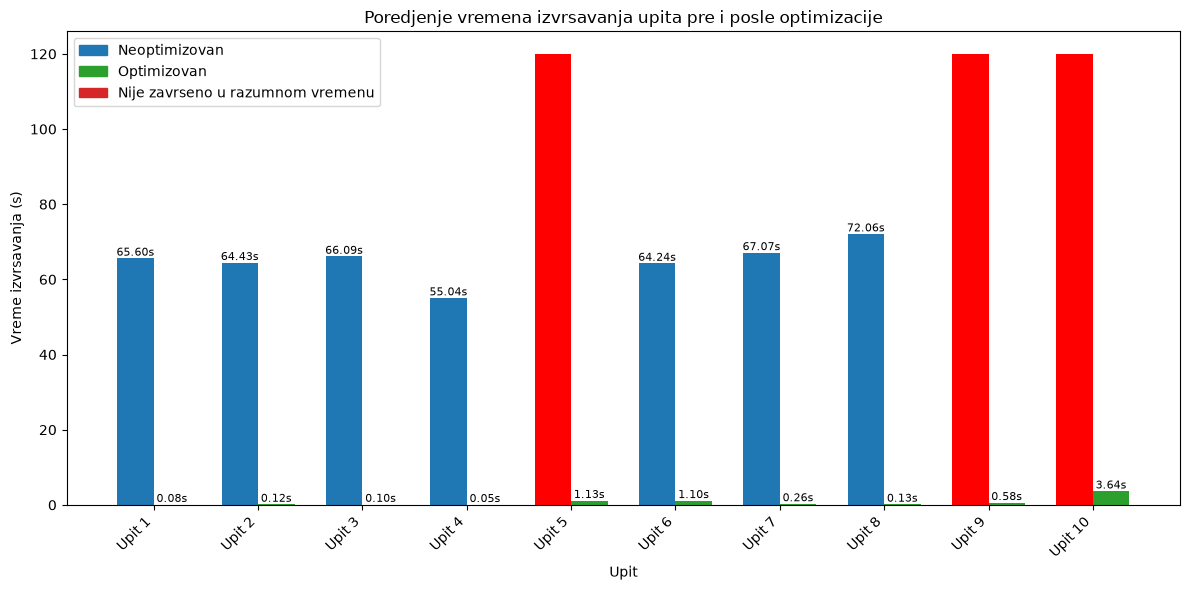

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

nazivi = [k for k in vremena if "neopt" in vremena[k] and "opt" in vremena[k]]
neopt = [vremena[k]["neopt"] for k in nazivi]
opt = [vremena[k]["opt"] for k in nazivi]

boje_neopt = ["red" if k in timeout_upiti else "tab:blue" for k in nazivi]

x = np.arange(len(nazivi))
sirina = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_neopt = ax.bar(x - sirina / 2, neopt, sirina, label="Neoptimizovan", color=boje_neopt)
bars_opt = ax.bar(x + sirina / 2, opt, sirina, label="Optimizovan", color="tab:green")

for i, naziv in enumerate(nazivi):
    if naziv not in timeout_upiti:
        ax.text(
            x[i] - sirina / 2,
            neopt[i],
            f"{neopt[i]:.2f}s",
            ha="center",
            va="bottom",
            fontsize=8
        )
    ax.text(
        x[i] + sirina / 2,
        opt[i],
        f"{opt[i]:.2f}s",
        ha="center",
        va="bottom",
        fontsize=8
    )

legenda = [
    Patch(color="tab:blue", label="Neoptimizovan"),
    Patch(color="tab:green", label="Optimizovan"),
    Patch(color="tab:red", label="Nije zavrseno u razumnom vremenu")
]

ax.set_xlabel("Upit")
ax.set_ylabel("Vreme izvrsavanja (s)")
ax.set_title("Poredjenje vremena izvrsavanja upita pre i posle optimizacije")
ax.set_xticks(x)
ax.set_xticklabels(nazivi, rotation=45, ha="right")
ax.legend(handles=legenda)

plt.tight_layout()
plt.show()